# Simulation CSV Plots

Set `CSV_PATH` below if you want a specific run. Leave it as `None` to use the newest `data/run_*.csv` file.

In [26]:
# Uncomment this if your notebook kernel does not have the plotting packages:
# %pip install pandas matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "misc":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Set this to a specific file if needed, for example:
# CSV_PATH = PROJECT_ROOT / "data" / "run_2026-06-07T19-54-22.csv"
CSV_PATH = None

if CSV_PATH is None:
    run_files = sorted((PROJECT_ROOT / "data").glob("run_*.csv"), key=lambda path: path.stat().st_mtime)
    if not run_files:
        raise FileNotFoundError("No data/run_*.csv files found")
    CSV_PATH = run_files[-1]

df = pd.read_csv(CSV_PATH)
df.head()

,epoch,population,food,bushes,avg_speed,avg_vision,avg_reproduction,max_generation,oldest_age,births,deaths,food_eaten
0,1,20,14,15,150.0,150.0,400.0,0,0.50,0,0,1
1,2,20,8,15,150.0,150.0,400.0,0,1.00,0,0,6
2,3,20,5,15,150.0,150.0,400.0,0,1.50,0,0,3
3,4,20,2,15,150.0,150.0,400.0,0,2.02,0,0,3
4,5,20,1,15,150.0,150.0,400.0,0,2.53,0,0,2


In [27]:
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
df.describe().T

Loaded: /Users/naresh/evolution/data/run_2026-06-07T23-57-18.csv
Rows: 1127


,count,mean,std,min,25%,50%,75%,max
epoch,1127.0,564.000000,325.481182,1.0,282.50,564.00,845.500,1127.00
population,1127.0,3.203194,3.018661,0.0,2.00,3.00,4.000,20.00
food,1127.0,23.423248,12.081396,0.0,14.00,21.00,31.500,45.00
bushes,1127.0,15.000000,0.000000,15.0,15.00,15.00,15.000,15.00
avg_speed,1127.0,121.687569,67.788735,0.0,147.95,153.12,162.630,185.23
avg_vision,1127.0,123.260018,69.881751,0.0,131.27,151.70,172.670,189.50
avg_reproduction,1127.0,292.101686,161.888265,0.0,359.91,379.45,386.960,400.00
max_generation,1127.0,5.353150,4.631294,0.0,0.00,5.00,9.000,14.00
oldest_age,1127.0,43.388784,35.565970,0.0,6.15,39.50,76.015,112.52
births,1127.0,0.030169,0.176240,0.0,0.00,0.00,0.000,2.00


In [28]:
def plot_columns(title, columns, normalize=False):
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    plot_df = df[["epoch", *columns]].copy()

    if normalize:
        for column in columns:
            min_value = plot_df[column].min()
            max_value = plot_df[column].max()
            if max_value != min_value:
                plot_df[column] = (plot_df[column] - min_value) / (max_value - min_value)

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for column in columns:
        ax.plot(plot_df["epoch"], plot_df[column], linewidth=2, label=column)

    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("normalized value" if normalize else "value")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.show()

## Plot 1: Population Dynamics

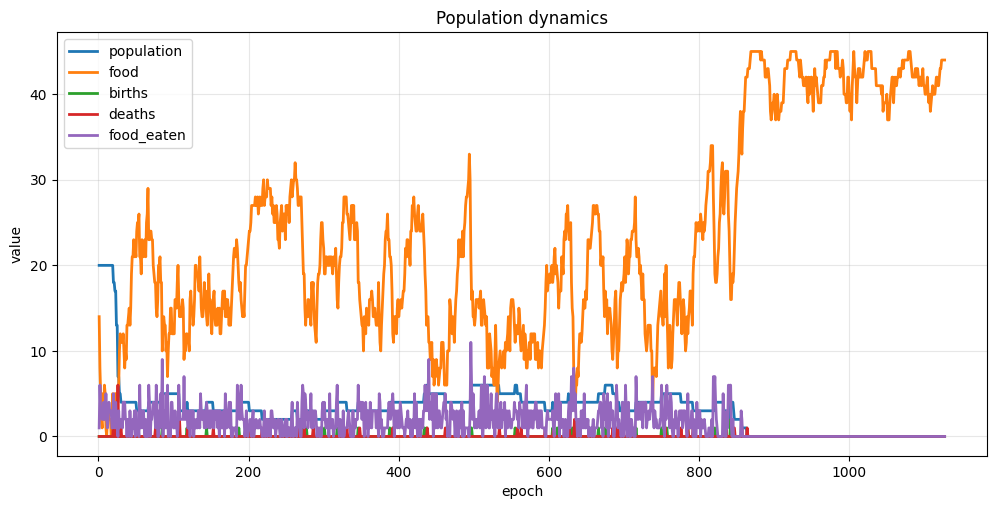

In [29]:
plot_columns(
    "Population dynamics",
    ["population", "food", "births", "deaths", "food_eaten"],
    normalize=False,
)

## Plot 2: Average Traits

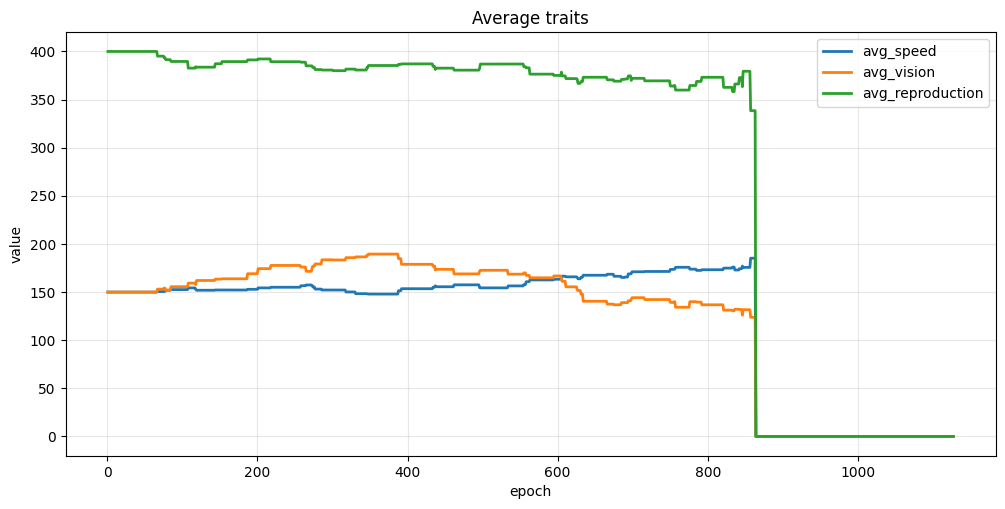

In [30]:
plot_columns(
    "Average traits",
    ["avg_speed", "avg_vision", "avg_reproduction"],
    normalize=False,
)

## Plot 3: Age And Generation

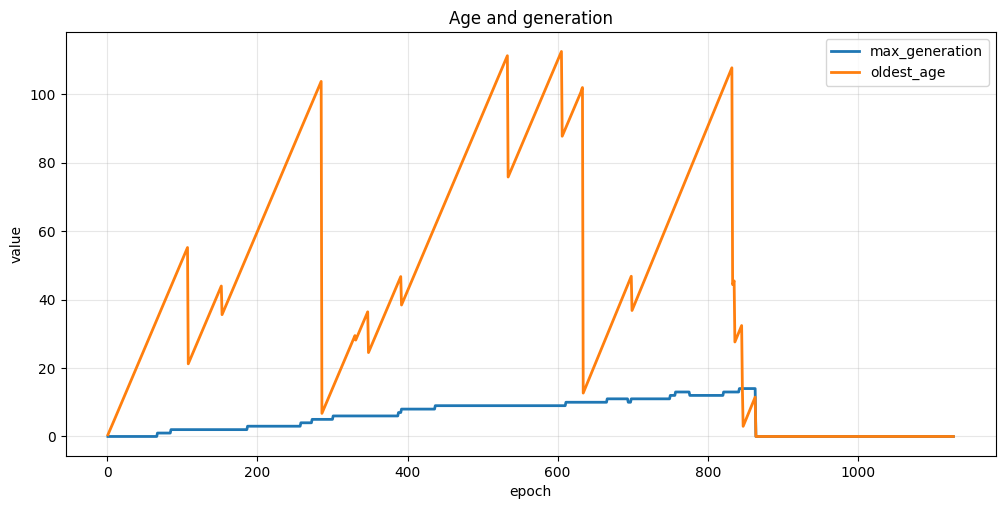

In [31]:
plot_columns(
    "Age and generation",
    ["max_generation", "oldest_age"],
    normalize=False,
)